# RFM in Action: Behavioral Segmentation for E-Commerce
### Phase 2 — RFM Segmentation & Clustering

**Goal:** Engineer customer-level behavioral features, evaluate clustering feasibility, and design interpretable, actionable customer segments.

In this phase, I build a customer-level feature table from transactional data and develop actionable customer segments. The goal is to understand how customers differ in purchasing behavior, identify high-value groups, and design targeted marketing strategies. I first engineer core behavioral features, test unsupervised clustering approaches, and ultimately construct interpretable RFM-based segments aligned with business use cases.

## Part A: Feature Design

Our first step is to utilize SQL to build the tables we need to perform our analysis. Using the `transactions_clean` dataset from Phase 1, we will create a customer-level feature table containing the core RFM metrics recency, frequency, and monetary value, as well as other lifecycle metrics such as first purchase, last purchase date, active lifespan, and average interpurchase gap.

These queries will be handled in Microsoft SQL Server, however, I will display snippets of the code here.

**`transactions_enriched`:**

``` sql
-- create new table with Revenue feature
SELECT 
	Invoice,
	StockCode,
	Description,
	Quantity,
	InvoiceDatetime AS InvoiceDate,
	Price,
	Customer_ID AS CustomerID,
	Country,
	Quantity * Price AS Revenue
INTO dbo.transactions_enriched
FROM dbo.transactions_clean;
```

**`customer_features`:**
``` sql
-- set RecencyReference to day after max transaction date to avoid 0-day recency for last-day purchasers
DECLARE @RecencyReference DATE = '2011-12-10';

-- create customer-level features table
SELECT
	CustomerID,
	-- lifecycle dates
	MIN(InvoiceDate) AS first_purchase_date,
	MAX(InvoiceDate) AS last_purchase_date,
	-- rfm metrics
	DATEDIFF(DAY, MAX(InvoiceDate), @RecencyReference) AS recency_days,
	COUNT(DISTINCT Invoice) AS frequency_orders,
	SUM(Revenue) AS monetary_total,
	SUM(Revenue) / NULLIF(COUNT(DISTINCT Invoice), 0) AS aov,
	-- lifecycle depth
	DATEDIFF(DAY, MIN(InvoiceDate), MAX(InvoiceDate)) AS active_lifespan_days,
	DATEDIFF(DAY, MIN(InvoiceDate), MAX(InvoiceDate)) / NULLIF(COUNT(DISTINCT Invoice), 0) AS interpurchase_gap,
	(SUM(Quantity) * 1.0) / NULLIF(COUNT(DISTINCT Invoice), 0) AS avg_items_per_order,
	-- avg price paid per unit
	SUM(Revenue) / NULLIF(SUM(Quantity), 0) AS avg_unit_price
FROM dbo.transactions_enriched
GROUP BY CustomerID;
```

In [1]:
# setup
import pandas as pd
import numpy as np
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
# load in customer_features and cohort_activity tables
customer_features = pd.read_csv("customer_features.csv")

## Part B: Segmentation with K-Means

### Transform and Scale Variables

We will use the clustering drivers:
- `recency_days`
- `frequency_orders`
- `monetary_total`
- `interpurchase_gap`

Since we will be performing K-means on our repeat customers, we need to filter to customers who made more than one purchase, that is `frequency_orders` greater than or equal to 2. 

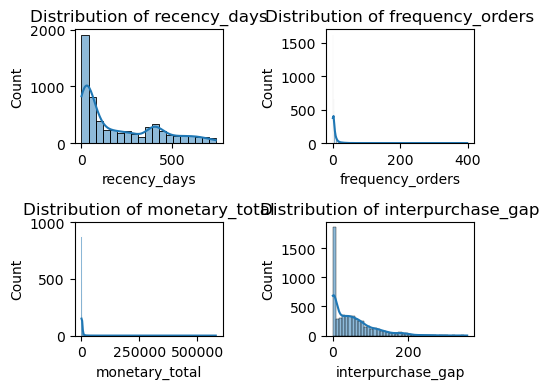

In [3]:
# filter to repeat customers
filtered_customers = customer_features[customer_features['frequency_orders'] >= 2].copy()

# select cluster features 
cluster_feats = [
    'recency_days',
    'frequency_orders',
    'monetary_total'
]

X = filtered_customers.copy()
fig, axes = plt.subplots(2, 2, figsize=(5, 4))

columns = ['recency_days', 'frequency_orders', 'monetary_total', 'interpurchase_gap']

for ax, col in zip(axes.flatten(), columns):
    sns.histplot(customer_features[col], ax=ax, kde=True)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

From the above plots, we notice that the `monetary_total` and `frequency_orders` are highly skewed to the right with extreme maximum values. Thus, we need to apply log transformations to prevent outliers from dominating during clustering. 

In [4]:
from sklearn.preprocessing import RobustScaler

# winsorize extreme values to reduce impact of outliers
# 1st-99th percentile per feature

LOW_Q, HIGH_Q = 0.01, 0.99

cap_bounds = {}
for col in cluster_feats:
    lo = X[col].quantile(LOW_Q)
    hi = X[col].quantile(HIGH_Q)
    cap_bounds[col] = (lo, hi)
    X[col] = X[col].clip(lower = lo, upper = hi)
    
# log-transform heavy-tailed variables (log(1+x))
    # monetary_total, frequency_orders, interpurchase_gap
    # ** we will keep recency_days untransformed
log_cols = ['monetary_total', 'frequency_orders']
for col in log_cols:
    X[col] = np.log1p(X[col])

# robust scaling (median/IQR) for k-means
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X[cluster_feats])
X_scaled_df = pd.DataFrame(X_scaled, columns = cluster_feats, index = filtered_customers.index)
X_scaled_df = pd.concat([X['CUSTOMERID'], X_scaled_df], axis=1)


Now our data is ready for modeling!

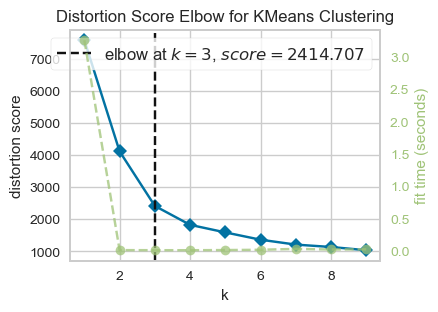

Optimal number of clusters (k):  3


In [5]:
# use elbow method to find optimal number of clusters

from yellowbrick.cluster import KElbowVisualizer

plt.figure(figsize=(4,3))
ax = plt.axes()
visualizer = KElbowVisualizer(KMeans(), k=(1, 10)) 
visualizer.fit(X_scaled_df[cluster_feats])
visualizer.show()

print("Optimal number of clusters (k): ", visualizer.elbow_value_)

In [6]:
# fit k-means
kmeans = KMeans(n_clusters = 3, random_state = 42)
filtered_customers['cluster'] = kmeans.fit_predict(X_scaled_df[cluster_feats])

# segment profiling table to view characteristics of each cluster
filtered_customers.groupby('cluster').agg(
    customers = ('CUSTOMERID', 'nunique'),
    recency_median=('recency_days', 'median'),
    frequency_median=('frequency_orders', 'median'),      
    monetary_median=('monetary_total', 'median'), 
    monetary_min=('monetary_total', 'min'),    
    monetary_max=('monetary_total', 'max'),      
    aov_median=('aov', 'median'), 
    lifespan_median=('active_lifespan_days', 'median'),
    interpurchase_gap_median=('interpurchase_gap', 'median'),
    avg_items_per_order_median =('avg_items_per_order', 'median'),
    avg_unit_price_median=('avg_unit_price', 'median')
)

,customers,recency_median,frequency_median,monetary_median,monetary_min,monetary_max,aov_median,lifespan_median,interpurchase_gap_median,avg_items_per_order_median,avg_unit_price_median
cluster,,,,,,,,,,,
0,1979,51.0,4.0,1013.17,30.95,9864.26,264.85,367.0,82.0,150.670,1.76
1,976,401.0,3.0,708.69,24.35,34095.26,243.39,156.0,49.0,127.500,1.94
2,1300,22.5,12.0,4855.68,1453.60,580987.04,372.91,626.0,42.0,213.985,1.82


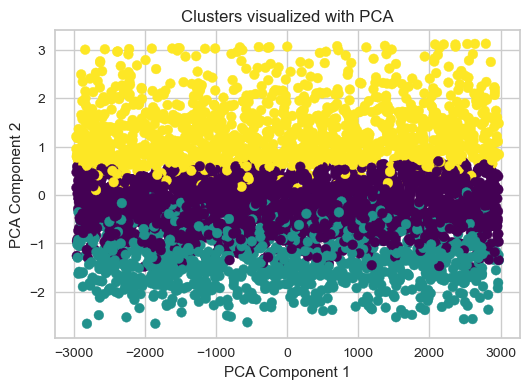

Silhouette Score: -0.016


In [7]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled_df)

# plot
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=filtered_customers['cluster'], cmap='viridis')
plt.title("Clusters visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# evaluate model using silhouette score
score = silhouette_score(X_scaled_df, filtered_customers['cluster'])
print(f"Silhouette Score: {score:.3f}")

From the above results, we conclude that KMeans clustering is not suitable for this dataset. After proper transformation and scaling, KMeans yielded a silhouette of -0.016 and the PCA visualization shows heavy overlap. The negative silhouette score indicates that customer observations overlap heavily across clusters, meaning there is no clear natural separation in behavioral space. This suggests that purchasing behavior in this dataset exists along continuous gradients rather than forming distinct, well-defined cluster groups. Therefore, a business-rule segmentation is more appropriate.

## Part C: Business-Driven RFM Segmentation

Since natural clusters were weak after transformation, I pivoted to an RFM-based rule segmentation to produce stable and interpretable business segments.

To begin our RFM analysis, we will score customers based on each attribute--Recency, Frequency, and Monetary Total--a value from 1 to 5.

We will first rank customers based on recency, that is, how recently a customer made a purchase. Individuals with more recent purchases are given higher scores. So, a higher `recency_days` value is given a lower score on the 1-5 scale.

We then rank customers based on frequency, how often they make a purchase. The more frequent the purchases, the higher the score. 

Lastly, we rank customers by monetary total with the highest spenders getting scored a value of 5 and the lowest spenders getting a score of 1.

In [8]:
rfm = customer_features.copy()

# scoring
# create 5 bins for each attribute
r_bins = min(rfm['recency_days'].nunique(), 5)
f_bins = min(rfm['frequency_orders'].nunique(), 5)
m_bins = min(rfm['monetary_total'].nunique(), 5)

# bin each col into quantiles and assign scores
# lower recency_days corresponds to more recent purchase --> higher recency score
rfm['r_score'] = pd.qcut(rfm['recency_days'], q = r_bins, labels = list(range(r_bins, 0, -1)), duplicates = 'drop').astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency_orders'].rank(method = 'first'), q = f_bins, labels = list(range(1, f_bins + 1)), duplicates = 'drop').astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary_total'].rank(method = 'first'), q = m_bins, labels = list(range(1, m_bins + 1)), duplicates = 'drop').astype(int)

rfm.head()

,CUSTOMERID,first_purchase_date,last_purchase_date,recency_days,frequency_orders,monetary_total,aov,active_lifespan_days,interpurchase_gap,avg_items_per_order,avg_unit_price,r_score,f_score,m_score
0,13992,2010-09-02 17:04:00.000,2011-11-09 15:23:00.000,31,3,219.50,73.17,433,144,51.33,1.43,4,3,1
1,14324,2010-01-15 13:31:00.000,2010-10-26 11:44:00.000,410,2,701.61,350.80,284,142,201.00,1.75,2,2,3
2,16671,2011-06-28 11:20:00.000,2011-11-11 13:40:00.000,29,3,1692.27,564.09,136,45,291.67,1.93,4,3,4
3,17550,2010-02-07 15:07:00.000,2011-05-26 14:09:00.000,198,9,2506.64,278.52,473,52,107.56,2.59,2,5,4
4,17218,2010-01-25 16:12:00.000,2011-12-05 13:52:00.000,5,18,3891.39,216.19,679,37,114.78,1.88,5,5,5


We will segment our customers into 10 categories:
- **Champions:** customers with the highest recency and frequency scores
- **Loyal Users:** customers with the highest frequency of interactions and strong recency scores
- **Potential Loyalists:** customers with recent purchases who demonstrate potential to convert to Champions or Loyal Users
- **New Users:** most recent customers with low frequency
- **Promising Users:** customers with strong recency and potential to become high-frequency users
- **Needing Attention:** customers with moderate recency and frequency but drifting engagement
- **About to Sleep:** customers with below-average recency and frequency scores that have the potential to slip away without engagement
- **At Risk:** once frequent customers with low recency
- **Cannot Lose Them:** once active customers without recent engagement
- **Hibernating:** customers with the lowest recency and frequency scores that may be lost permanently.

In [9]:
# rule-based rfm segments

# assign in priority order to ensure mutual exclusivity
conditions = [
    # champions: high on all 3
    (rfm['r_score'] >= 4) & (rfm['f_score'] >= 4),

    # loyal: high frequency, strong recency
    (rfm['f_score'] >= 4) & (rfm['r_score'].between(2, 3)),

    # potential loyalist: strong recency, potential to be champion/loyal
    (rfm['r_score'] >= 4) & (rfm['f_score'].between(2, 3)),

    # new customers: very recent, low freq (1-2 orders)
    (rfm['r_score'] == 5) & (rfm['f_score'] == 1),

    # promising: high recency, potential to be high-freq
    (rfm['r_score'] == 4) & (rfm['f_score'] == 1),

    # need attention: mid-recency, low frequency, low spend
    (rfm['r_score'] == 3) & (rfm['f_score'].between(1, 2)),

    # about to sleep
    (rfm['r_score'] == 2) & (rfm['f_score'].between(1, 2)),

    # at risk
    (rfm['r_score'].between(2, 3)) & (rfm['f_score'] >= 3),

    # cannot lose them
    (rfm['r_score'] == 1) & (rfm['f_score'] >= 3),

    # hiberating: low recency, low freq
    (rfm['r_score'] == 1) & (rfm['f_score'].between(1, 2))
]

categories = [
    'Champions',
    'Loyal',
    'Potential Loyalist',
    'New Customers',
    'Promising',
    'Need Attention',
    'About to Sleep',
    'At Risk',
    'Cannot Lose Them',
    'Hibernating'
]

# assign customers to segments based on conditions
rfm['segment'] = np.select(conditions, categories)

# download rfm df to csv for later querying
# rfm.to_csv('rfm.csv')

In [10]:
# segment size dist
segment_sizes = (
    rfm['segment'].value_counts(dropna = False)
    .rename_axis('segment')
    .reset_index(name = 'customers')
)
segment_sizes['pct_customers'] = segment_sizes ['customers'] / segment_sizes['customers'].sum()

# segment profile table 
profile = (
    rfm.groupby('segment').agg(
        customers = ('CUSTOMERID', 'count'),
        recency_median = ('recency_days', 'median'),
        frequency_median = ('frequency_orders', 'median'),
        monetary_median = ('monetary_total', 'median'),
        aov_median = ('aov', 'median'),
        interpurchase_gap_median = ('interpurchase_gap', 'median'),
        lifespan_median = ('active_lifespan_days', 'median'),
        r_avg = ('r_score', 'mean'),
        f_avg = ('f_score', 'mean'),
        m_avg = ('m_score', 'mean')
    )
    .sort_values('customers', ascending = False)
    .reset_index()
)

display(profile)

,segment,customers,recency_median,frequency_median,monetary_median,aov_median,interpurchase_gap_median,lifespan_median,r_avg,f_avg,m_avg
0,Champions,1484,17.0,10.0,3365.270,322.405,48.0,616.0,4.585580,4.607817,4.419811
1,Hibernating,896,556.0,1.0,250.680,221.740,0.0,0.0,1.000000,1.409598,1.651786
2,Loyal,776,132.0,7.0,2022.460,294.540,63.0,470.5,2.668814,4.332474,4.001289
3,Potential Loyalist,698,25.0,3.0,676.995,268.420,60.0,172.5,4.409742,2.613181,2.650430
4,About to Sleep,632,320.0,1.0,307.495,234.905,0.0,0.0,2.000000,1.517405,1.786392
5,At Risk,567,191.0,3.0,824.590,277.020,92.0,305.0,2.495591,3.000000,2.915344
6,Need Attention,380,93.5,1.0,355.740,285.115,0.0,0.0,3.000000,1.555263,1.957895
7,Cannot Lose Them,272,478.0,3.0,948.760,268.275,37.0,140.5,1.000000,3.393382,3.102941
8,Promising,113,39.0,1.0,225.120,225.120,0.0,0.0,4.000000,1.000000,1.557522
9,New Customers,60,12.0,1.0,263.035,263.035,0.0,0.0,5.000000,1.000000,1.566667


The segment profile table above depicts the behavior of each segment across recency, frequency, and monetary dimensions. As shown, the **Champions** segment displays the lowest median recency (most recent purchases), highest median order frequency, and highest median monetary value, confirming the represent the most valuable active customers. Conversely, **Hibernating** customers show the highest median recency (longest time since last purchase), lowest purchase frequency, and lowest spending, aligning with disengaged or lost customers. Transitional segments such as **Potential Loyalists** and **At Risk customers** fall between these two extremes with intermediate recency and frequency values. The consistent ordering across RFM metrics confirms that the rule-based segmentation produces coherent and interpretable customer groups suitable for targeted marketing strategy.

### Visualize Segment Distribution

I visualize segment sizes to understand population balance across behavioral groups. This highlights the relative proportion of high-value versus low-engagement customers and provides insight into where marketing resources may yield the greatest return.

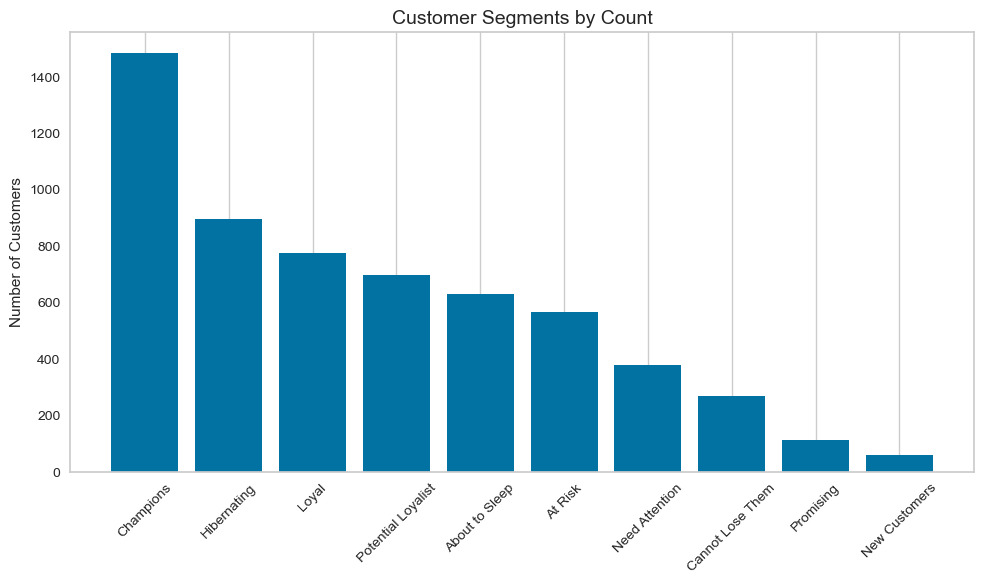

In [11]:
# bar chart 
plt.figure(figsize = (10, 6))
plt.bar(profile['segment'], profile['customers'])
plt.title('Customer Segments by Count', fontsize = 14)
plt.ylabel('Number of Customers')
plt.xticks(rotation = 45)
plt.grid(axis = 'y')
plt.tight_layout()
plt.show()

In [12]:
# pie chart
import plotly.express as px

fig = px.pie(profile, values = 'customers', names = 'segment', 
             title = 'Customer Segments by Percentage',
             hover_data = ['customers'])
fig.show()

### Revenue Contribution by Segment

Which segments drive revenue?

In [13]:
# group by segment and calculate total revenue of each group
revenue_overview = pd.DataFrame(rfm.groupby('segment')['monetary_total'].agg('sum'))

# calculate total revenue across all groups
total_rev = revenue_overview['monetary_total'].sum() 

# calculate each group's percentage of total revenue
revenue_overview['percent_of_total_rev'] = (revenue_overview['monetary_total'] / total_rev)

# sort highest to lowest percentage to find biggest drivers
revenue_overview = revenue_overview.sort_values('percent_of_total_rev', ascending = False)

# formatting
revenue_overview.columns = ['Revenue', 'Percent of Total Revenue']
revenue_overview['Percent of Total Revenue'] = revenue_overview['Percent of Total Revenue'].map('{:.2%}'.format)

display(revenue_overview)

,Revenue,Percent of Total Revenue
segment,,
Champions,12023528.93,69.20%
Loyal,2536548.46,14.60%
Potential Loyalist,788827.60,4.54%
At Risk,653594.76,3.76%
Cannot Lose Them,464167.85,2.67%
Hibernating,376425.29,2.17%
About to Sleep,274712.60,1.58%
Need Attention,197989.37,1.14%
Promising,37696.22,0.22%


I calculate total revenue contribution per segment to quantify which behavioral groups drive business value. Champions alone contribute roughly 69% of total revenue, followed by Loyal customers. This concentration reveals that retention and loyalty programs targeting top segments will have disproportionate impact on revenue stability.

### Recommended Business Actions

| Segment | Recommended Action |
|:--------:|:--------:|
| Champions | Loyalty perks, VIP | 
| Loyal | Upsell bundles | 
| Potential Loyalist | Nurture campaigns | 
| New | Onboarding email |
| Promising | Incentivize 2nd purchase |
| Need Attention | Reminder offers |
| About to Sleep | Reactivation discount |
| At Risk | Win-back campaign |
| Cannot Lose Them | Personal outreach |
| Hibernating | Remove from paid targeting |

Finally, I translate segment insights into concrete marketing actions. Examples include VIP loyalty perks for Champions, nurture campaigns for Potential Loyalists, win-back outreach for At Risk customers, and suppression from paid targeting for Hibernating customers. This closes the loop between analytical segmentation and real business decision-making.

These targeted interventions are expected to increase repeat purchase rate, improve long-term retention, and raise average customer lifetime value by concentrating marketing resources on high-value and high-potential segments.

## Executive Summary

**Key findings:**
- Champions = 18% of customers driving 69% of revenue
- Loyal + Potential Loyalist = 25% driving ~19% revenue
- ~32% customers are at-risk or hibernating